# Field map II — Transverse structure, multipole content & Maxwell checks

Notebook 01 covered identity/geometry/on-axis. Here we characterise the **3-D structure** that makes the real field hard: how B_y varies off-axis, the fringe components, the **multipole-fit accuracy ceiling** (why a global-polynomial chart only reaches ~mm on the real field), numerical Maxwell consistency, and the field actually traversed by tracks.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from field_v8r1 import FieldV8R1

FIG = Path('figures'); FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
CVMFS = '/cvmfs/lhcb.cern.ch/lib/lhcb/DBASE/FieldMap/v5r11/cdf'
f = FieldV8R1(f'{CVMFS}/field.v8r1.down.bin')
d = 1.0/f.invD; mn = f.min; N = f.N
Bx, By, Bz = (f.Bx*f.scale, f.By*f.scale, f.Bz*f.scale)   # (z,y,x), Tesla
print('arrays (z,y,x):', By.shape, ' Tesla')

arrays (z,y,x): (146, 81, 81)  Tesla


## 1 · 2-D slices of B_y

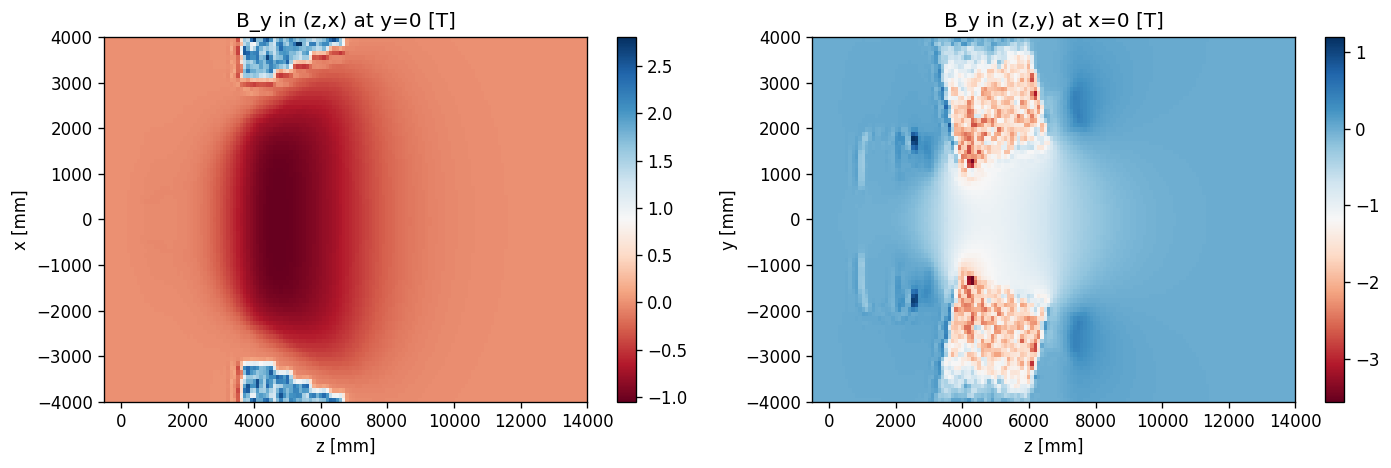

In [2]:
iy0 = int(round((0-mn[1])*f.invD[1]))  # y=0 plane
ix0 = int(round((0-mn[0])*f.invD[0]))  # x=0 plane
ext_zx = [mn[2], mn[2]+(N[2]-1)*d[2], mn[0], mn[0]+(N[0]-1)*d[0]]
ext_zy = [mn[2], mn[2]+(N[2]-1)*d[2], mn[1], mn[1]+(N[1]-1)*d[1]]
fig, ax = plt.subplots(1, 2, figsize=(12,4))
im0 = ax[0].imshow(By[:, iy0, :].T, origin='lower', aspect='auto', extent=ext_zx, cmap='RdBu')
ax[0].set_title('B_y in (z,x) at y=0 [T]'); ax[0].set_xlabel('z [mm]'); ax[0].set_ylabel('x [mm]'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(By[:, :, ix0].T, origin='lower', aspect='auto', extent=ext_zy, cmap='RdBu')
ax[1].set_title('B_y in (z,y) at x=0 [T]'); ax[1].set_xlabel('z [mm]'); ax[1].set_ylabel('y [mm]'); plt.colorbar(im1, ax=ax[1])
fig.tight_layout(); fig.savefig(FIG/'fieldmap_slices_by.png'); plt.show()

## 2 · Off-axis (transverse) growth at the magnet centre — the localised structure

B_y(0,0,5000)      = -1.0341 T
B_y(2000,0)/B_y(0,0) = 0.853
B_y(0,1800)/B_y(0,0) = 1.954   (non-monotonic, grows off-axis)


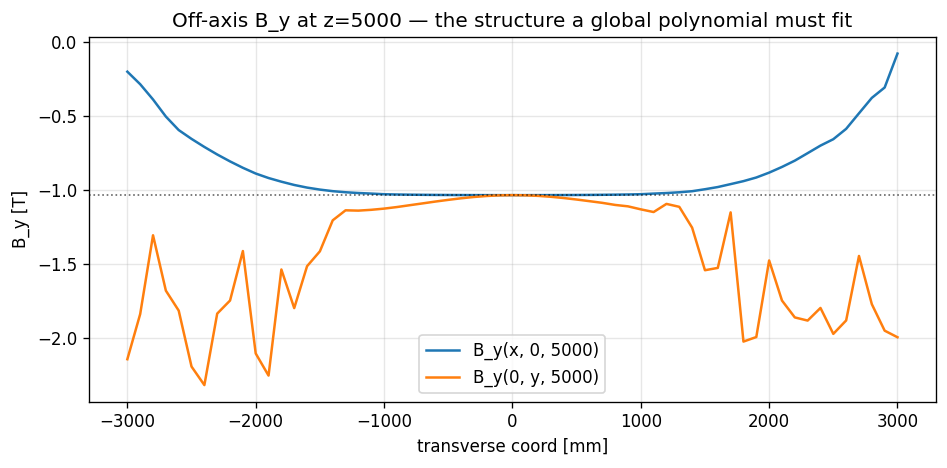

In [3]:
zc = 5000.0
gx = np.linspace(-3000, 3000, 121); zc0 = np.full_like(gx, zc)
By_x = f(gx, np.zeros_like(gx), zc0)[1]        # along x, y=0
By_y = f(np.zeros_like(gx), gx, zc0)[1]        # along y, x=0
b00 = f(0,0,zc)[1]
print(f'B_y(0,0,{zc:.0f})      = {b00:+.4f} T')
print(f'B_y(2000,0)/B_y(0,0) = {f(2000,0,zc)[1]/b00:.3f}')
print(f'B_y(0,1800)/B_y(0,0) = {f(0,1800,zc)[1]/b00:.3f}   (non-monotonic, grows off-axis)')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(gx, By_x, label='B_y(x, 0, 5000)'); ax.plot(gx, By_y, label='B_y(0, y, 5000)')
ax.axhline(b00, color='k', ls=':', lw=1, alpha=0.6); ax.grid(alpha=0.3)
ax.set_xlabel('transverse coord [mm]'); ax.set_ylabel('B_y [T]')
ax.set_title('Off-axis B_y at z=5000 — the structure a global polynomial must fit'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'fieldmap_transverse_by.png'); plt.show()

## 3 · Fringe components B_x, B_z off-axis (Maxwell-forced)

max |B_x| along y (z=5000) = 0.660 T
max |B_z| along x (z=5000) = 0.003 T


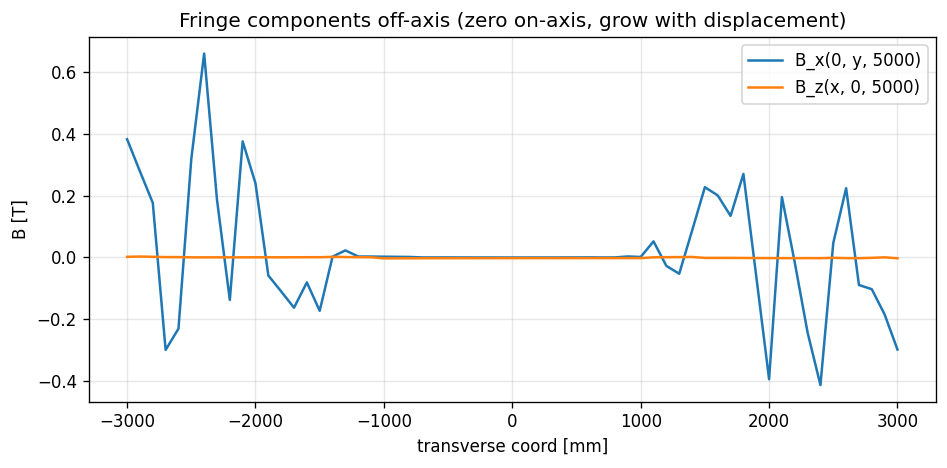

In [4]:
Bx_y = f(np.zeros_like(gx), gx, zc0)[0]
Bz_x = f(gx, np.zeros_like(gx), zc0)[2]
print(f'max |B_x| along y (z=5000) = {np.abs(Bx_y).max():.3f} T')
print(f'max |B_z| along x (z=5000) = {np.abs(Bz_x).max():.3f} T')
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(gx, Bx_y, label='B_x(0, y, 5000)'); ax.plot(gx, Bz_x, label='B_z(x, 0, 5000)')
ax.set_xlabel('transverse coord [mm]'); ax.set_ylabel('B [T]'); ax.grid(alpha=0.3)
ax.set_title('Fringe components off-axis (zero on-axis, grow with displacement)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG/'fieldmap_fringe.png'); plt.show()

## 4 · Multipole-fit accuracy ceiling (why the global-multipole chart fails)
Fit B_y(x,y) at z=5000 over the chord window with an **even** polynomial basis $\sum c_{ab}(x/X_N)^a(y/Y_N)^b$ (a,b even). Report the fit RMS vs order — it plateaus, and the residual concentrates at the window edges (Runge ringing on the localised structure).

 order  #coef   RMS[mT]  rel.med[%]
     2      3    310.75        7.25
     4      6    292.44        7.35
     6     10    249.56        9.16
     8     15    208.96        5.17
    10     21    195.12        4.27
    12     28    176.12        5.44
    16     45    133.24        3.42
    20     66    116.94        2.23


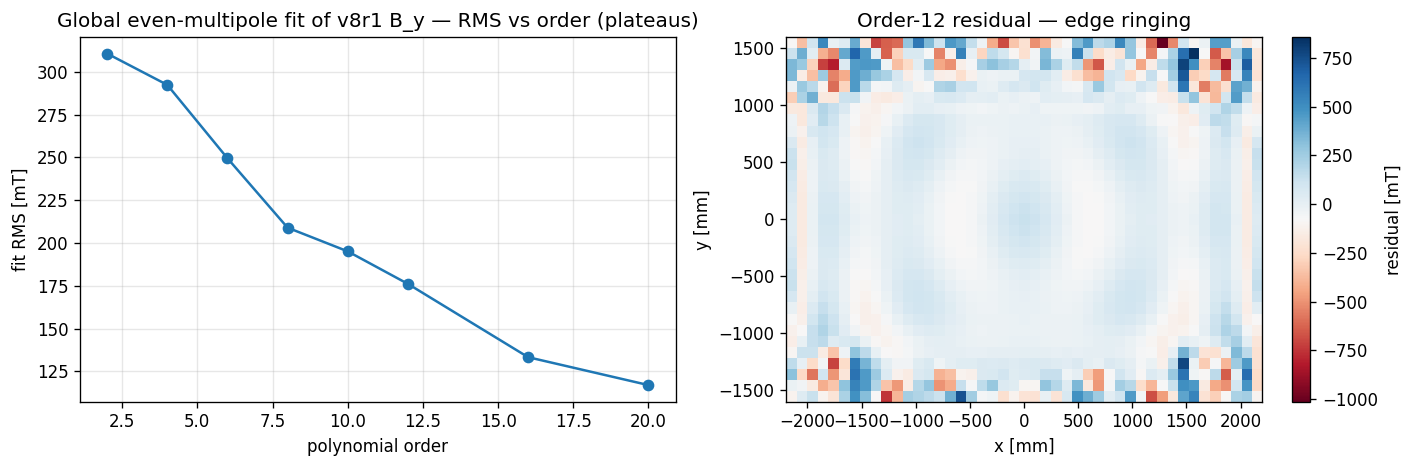

In [5]:
XW, YW = 2200.0, 1600.0
gxx = np.linspace(-XW, XW, 45); gyy = np.linspace(-YW, YW, 33)
GX, GY = np.meshgrid(gxx, gyy)
Bsamp = f(GX.ravel(), GY.ravel(), np.full(GX.size, zc))[1]
xn, yn = GX.ravel()/XW, GY.ravel()/YW
def even_design(xn, yn, order):
    cols = []
    for a in range(0, order+1, 2):
        for b in range(0, order+1-a, 2):
            cols.append((xn**a)*(yn**b))
    return np.stack(cols, axis=1)
orders = [2,4,6,8,10,12,16,20]
rms, relmed, ncoef = [], [], []
res12 = None
for O in orders:
    A = even_design(xn, yn, O)
    c, *_ = np.linalg.lstsq(A, Bsamp, rcond=None)
    res = Bsamp - A@c
    rms.append(np.sqrt(np.mean(res**2))*1e3)            # mT
    relmed.append(np.median(np.abs(res))/np.median(np.abs(Bsamp))*100)  # %
    ncoef.append(A.shape[1])
    if O == 12: res12 = res.reshape(GY.shape)
print(f"{'order':>6}{'#coef':>7}{'RMS[mT]':>10}{'rel.med[%]':>12}")
for O,n,r,rm in zip(orders,ncoef,rms,relmed): print(f'{O:>6}{n:>7}{r:>10.2f}{rm:>12.2f}')
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(orders, rms, 'o-'); ax[0].set_xlabel('polynomial order'); ax[0].set_ylabel('fit RMS [mT]')
ax[0].set_title('Global even-multipole fit of v8r1 B_y — RMS vs order (plateaus)'); ax[0].grid(alpha=0.3)
im = ax[1].imshow(res12*1e3, origin='lower', aspect='auto', cmap='RdBu',
                  extent=[-XW,XW,-YW,YW]); plt.colorbar(im, ax=ax[1], label='residual [mT]')
ax[1].set_xlabel('x [mm]'); ax[1].set_ylabel('y [mm]'); ax[1].set_title('Order-12 residual — edge ringing')
fig.tight_layout(); fig.savefig(FIG/'fieldmap_multipole_ceiling.png'); plt.show()

## 5 · Numerical Maxwell consistency (∇·B ≈ 0, ∇×B ≈ 0)
In the current-free tracking volume both should vanish; finite values are dominated by the 100 mm grid resolution and bound the field's smoothness.

In [6]:
dz, dy, dx = d[2], d[1], d[0]
gBx = np.gradient(Bx, dz, dy, dx); gBy = np.gradient(By, dz, dy, dx); gBz = np.gradient(Bz, dz, dy, dx)
# gradient returns [d/dz, d/dy, d/dx]
divB  = gBx[2] + gBy[1] + gBz[0]
curlx = gBz[1] - gBy[0]; curly = gBx[0] - gBz[2]; curlz = gBy[2] - gBx[1]
curl  = np.sqrt(curlx**2 + curly**2 + curlz**2)
# interior tracking volume
zc_ = mn[2] + np.arange(N[2])*dz; yc_ = mn[1] + np.arange(N[1])*dy; xc_ = mn[0] + np.arange(N[0])*dx
ZZ, YY, XX = np.meshgrid(zc_, yc_, xc_, indexing='ij')
interior = (np.abs(XX)<3000)&(np.abs(YY)<2500)&(ZZ>0)&(ZZ<10000)
print(f'|grad.B|  in tracking volume: median {np.median(np.abs(divB[interior]))*1e3:.4f} mT/mm, '
      f'p99 {np.quantile(np.abs(divB[interior]),0.99)*1e3:.3f} mT/mm')
print(f'|curl B|  in tracking volume: median {np.median(curl[interior])*1e3:.4f} mT/mm, '
      f'p99 {np.quantile(curl[interior],0.99)*1e3:.3f} mT/mm')
print('(reference: dBy/dz on axis ~ '
      f'{np.abs(np.gradient(f(np.zeros(200),np.zeros(200),np.linspace(2000,8000,200))[1],np.linspace(2000,8000,200))).max()*1e3:.2f} mT/mm)')

|grad.B|  in tracking volume: median 0.0154 mT/mm, p99 8.854 mT/mm
|curl B|  in tracking volume: median 0.0248 mT/mm, p99 14.446 mT/mm
(reference: dBy/dz on axis ~ 0.60 mT/mm)


## 6 · The field tracks actually traverse + the raw peak

In [7]:
absB = np.sqrt(Bx**2 + By**2 + Bz**2)
iz, iy, ix = np.unravel_index(np.argmax(absB), absB.shape)
print(f'raw peak |B| = {absB[iz,iy,ix]:.3f} T at (x,y,z) = '
      f'({mn[0]+ix*dx:.0f}, {mn[1]+iy*dy:.0f}, {mn[2]+iz*dz:.0f}) mm')
# field along a representative PV-pointing chord into the magnet (tx=0.2, ty=0.1)
zc2 = np.linspace(0, 9000, 200); xc2 = 0.2*zc2; yc2 = 0.1*zc2
Bchord = np.sqrt(np.sum(np.array(f(xc2, yc2, zc2))**2, axis=0))
print(f'|B| along a (tx=0.2,ty=0.1) pointing chord: max {Bchord.max():.3f} T, '
      f'reaches (x,y)=({xc2[-1]:.0f},{yc2[-1]:.0f}) mm by z=9000')
print('=> PV-pointing tracks DO traverse the strong, locally-structured region — the hard part for any surrogate.')

raw peak |B| = 5.766 T at (x,y,z) = (2900, 2300, 5700) mm
|B| along a (tx=0.2,ty=0.1) pointing chord: max 1.095 T, reaches (x,y)=(1800,900) mm by z=9000
=> PV-pointing tracks DO traverse the strong, locally-structured region — the hard part for any surrogate.


## Findings
1. **The field is genuinely 3-D and locally structured.** B_y grows off-axis (it is *not* a clean on-axis dipole); fringe B_x, B_z are non-zero off the midplane (Maxwell-forced).
2. **Global multipole hits an accuracy ceiling** (~few-% RMS that does not improve with order; residual rings at the window edges) — the quantitative reason the global-multipole chart floors at ~mm on the real field, while extrapUTT's *per-bin local* fits succeed.
3. **Maxwell holds numerically** to the grid-resolution level (small ∇·B, ∇×B in the tracking volume) — the map is internally consistent; the limitation is its 100 mm sampling, which is also exactly what Allen interpolates.
4. **Tracks traverse the hard region:** PV-pointing chords reach large |x|,|y| where |B| is strong and structured (raw peak ~5 T) — surrogate accuracy is set there.
5. **vs the toy `twodip` field (v1, wrong):** ~1.4% weaker on-axis, sign-flipped, ~2% multipole-fittable (artificially smooth) — which is why the toy 12 µm chart did not transfer (see archive/03).